In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.signal import savgol_filter
from scan_spectrolyser import scan_helpers
from scan_spectrolyser import no3_calibrations

In [3]:
def fit_linear_function(linear_range, x, y):
    coeff = np.polyfit(linear_range[x], linear_range[y], 1)
    r2 = np.corrcoef(linear_range[x], linear_range[y])[0,1]**2
    return coeff, r2

def plot_linear_fit(data, linear_range, x, y, text_start_x, text_start_y, text_y_spacing, ax):
    coeff, r2 = fit_linear_function(linear_range, x, y)
    vals= np.polyval(coeff, data[x])
    ax.plot(data[x], vals, color='b')
    ax.text(text_start_x, text_start_y, 'Slope: %.4f' % (coeff[0]))
    ax.text(text_start_x, text_start_y - text_y_spacing, 'Intercept: %.4f' % (coeff[1]))
    ax.text(text_start_x, text_start_y - 2*text_y_spacing, 'R2: %.4f' % (r2))
    return coeff, r2

# Chinese S::CAN

## New calibration with freshly made standards

In [20]:
chinesecal_21425 = scan_helpers.import_scan_fp('/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/Boise Project/Data/SCAN Calibration 2-14-25/calibration.fp')
chinesecal_21425['Concentration (mg/L)'] = [0, .01, .05, .1, .5, 1, 2]
chinesecal_21425['Concentration (uM)'] = chinesecal_21425['Concentration (mg/L)']*1000/14
chinesecal_21425 = scan_helpers.apply_calibrations(chinesecal_21425, [no3_calibrations.one_wavelength, no3_calibrations.two_wavelength, no3_calibrations.second_derivative], {no3_calibrations.second_derivative: {'output_calibrated':False}, no3_calibrations.two_wavelength: {'output_calibrated':False}, no3_calibrations.one_wavelength: {'output_calibrated':False}})

chinesecal_21425_corrected = scan_helpers.correct_turbidity(chinesecal_21425.drop(['Concentration (mg/L)', 'Concentration (uM)', 'one_wavelength', 'two_wavelength', 'second_derivative'], axis=1))
chinesecal_21425_corrected['Concentration (mg/L)'] = [0, .01, .05, .1, .5, 1, 2]
chinesecal_21425_corrected['Concentration (uM)'] = chinesecal_21425['Concentration (mg/L)']*1000/14
chinesecal_21425_corrected = scan_helpers.apply_calibrations(chinesecal_21425_corrected, [no3_calibrations.one_wavelength, no3_calibrations.two_wavelength, no3_calibrations.second_derivative], {no3_calibrations.second_derivative: {'output_calibrated':False}, no3_calibrations.two_wavelength: {'output_calibrated':False}, no3_calibrations.one_wavelength: {'output_calibrated':False}})

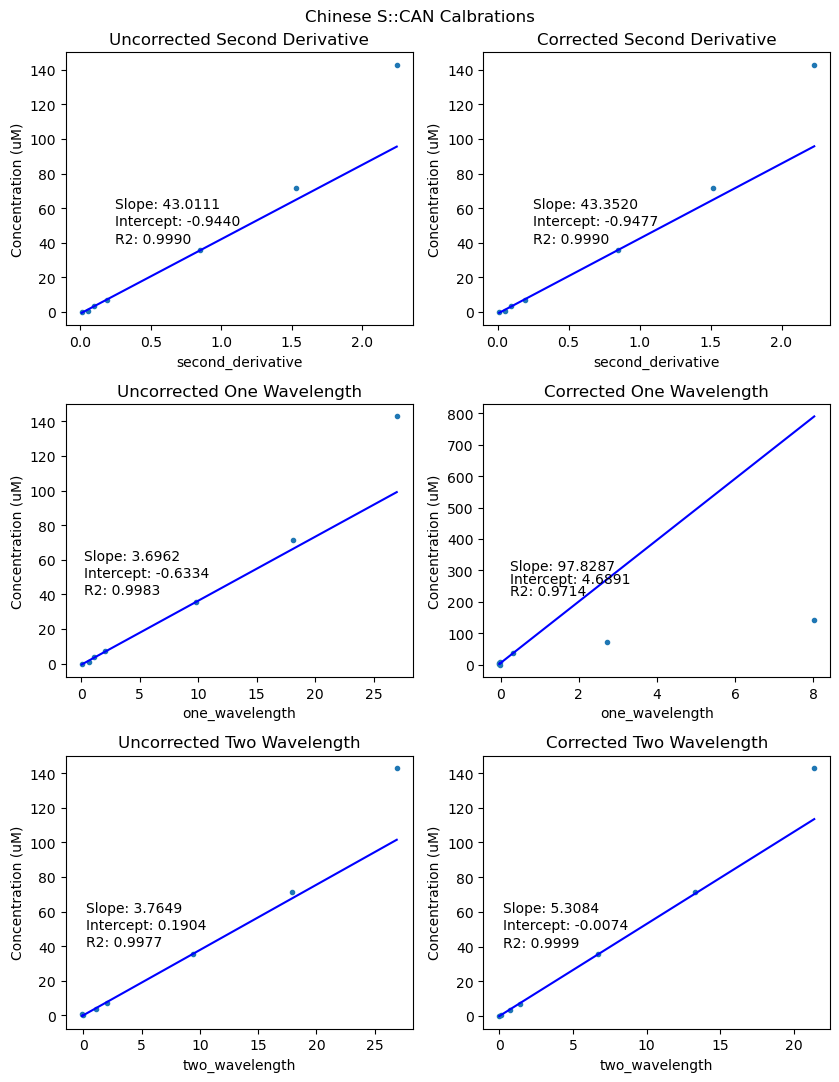

In [40]:
fig, ax = plt.subplots(nrows=3,ncols=2, figsize=(8.5,11))
chinesecal_21425.plot(y='Concentration (uM)', x='second_derivative', marker='.', linestyle = 'None', title = 'Uncorrected Second Derivative', ylabel = 'Concentration (uM)', legend=False, ax=ax[0,0])
plot_linear_fit(chinesecal_21425, chinesecal_21425[0:5], 'second_derivative', 'Concentration (uM)', .25, 60, 10, ax=ax[0,0])

chinesecal_21425.plot(y='Concentration (uM)', x='one_wavelength', marker='.', linestyle = 'None', title = 'Uncorrected One Wavelength', ylabel = 'Concentration (uM)', legend=False, ax=ax[1,0])
plot_linear_fit(chinesecal_21425, chinesecal_21425[0:5], 'one_wavelength', 'Concentration (uM)', .25, 60, 10, ax=ax[1,0])

chinesecal_21425.plot(y='Concentration (uM)', x='two_wavelength', marker='.', linestyle = 'None', title = 'Uncorrected Two Wavelength', ylabel = 'Concentration (uM)', legend=False, ax=ax[2,0])
plot_linear_fit(chinesecal_21425, chinesecal_21425[0:5], 'two_wavelength', 'Concentration (uM)', .25, 60, 10, ax=ax[2,0])

chinesecal_21425_corrected.plot(y='Concentration (uM)', x='second_derivative', marker='.', linestyle = 'None', title = 'Corrected Second Derivative', ylabel = 'Concentration (uM)', legend=False, ax=ax[0,1])
plot_linear_fit(chinesecal_21425_corrected, chinesecal_21425_corrected[0:5], 'second_derivative', 'Concentration (uM)', .25, 60, 10, ax=ax[0,1])

chinesecal_21425_corrected.plot(y='Concentration (uM)', x='one_wavelength', marker='.', linestyle = 'None', title = 'Corrected One Wavelength', ylabel = 'Concentration (uM)', legend=False, ax=ax[1,1])
plot_linear_fit(chinesecal_21425_corrected, chinesecal_21425_corrected[0:5], 'one_wavelength', 'Concentration (uM)', .25, 300, 40, ax=ax[1,1])

chinesecal_21425_corrected.plot(y='Concentration (uM)', x='two_wavelength', marker='.', linestyle = 'None', title = 'Corrected Two Wavelength', ylabel = 'Concentration (uM)', legend=False, ax=ax[2,1])
plot_linear_fit(chinesecal_21425_corrected, chinesecal_21425_corrected[0:5], 'two_wavelength', 'Concentration (uM)', .25, 60, 10, ax=ax[2,1])


fig.suptitle('Chinese S::CAN Calbrations')
fig.tight_layout()

- This calibration looks great! 
- linear up until 0.5 mg/L, non linear above that - will have to check with turbidity if still linear.
- for reference, in Reynolds we were seeing ~ 10 uM (.14 mg/L). So this range seems very reasonable
- correction has little effect on 2nd derivative calibration
- correction seriously messes up one-wavelength, but stil works really well for two_wavelength - even more linear than second derivative, up to 80 uM (1.1 uM)s

## Calibration made with old standards
- these are based off of erroneous SEAL standard

In [5]:
chinesecal_21425_old = scan_helpers.import_scan_fp('/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/Boise Project/Data/SCAN Calibration 2-14-25/calibration_old.fp')
chinesecal_21425_old['Concentration (mg/L)'] = [0, .01, .05, .1, .5, 1, 2]
chinesecal_21425_old['Concentration (mg/L) Correct'] = chinesecal_21425_old['Concentration (mg/L)']*1.168
chinesecal_21425_old = scan_helpers.apply_calibrations(chinesecal_21425_old, [no3_calibrations.one_wavelength, no3_calibrations.two_wavelength, no3_calibrations.second_derivative], {no3_calibrations.second_derivative: {'output_calibrated':False}, no3_calibrations.two_wavelength: {'output_calibrated':False}, no3_calibrations.one_wavelength: {'output_calibrated':False}})

chinesecal_21425_old

,200.0,202.5,205.0,207.5,210.0,212.5,215.0,217.5,220.0,222.5,...,740.0,742.5,745.0,747.5,750.0,Concentration (mg/L),Concentration (mg/L) Correct,one_wavelength,two_wavelength,second_derivative
Date/Time,,,,,,,,,,,,,,,,,,,,,
2025-02-14 20:30:12,0.0826,0.0666,0.0752,0.0589,0.0508,0.0435,0.0547,0.0473,0.0295,0.0210,...,0.0118,NaN,NaN,NaN,NaN,0.00,0.00000,0.0295,-0.0209,0.0106
2025-02-14 20:32:44,0.9898,0.9099,0.8402,0.7612,0.6769,0.5760,0.4679,0.3740,0.2757,0.1968,...,-0.0520,NaN,NaN,NaN,NaN,0.01,0.01168,0.2757,0.3057,0.0392
2025-02-14 20:36:24,3.3421,3.2198,3.1041,2.9418,2.6811,2.3687,1.9869,1.5580,1.1399,0.8162,...,-0.1024,NaN,NaN,NaN,NaN,0.05,0.05840,1.1399,1.1881,0.1101
2025-02-14 20:40:01,6.7109,6.4952,6.2287,5.8864,5.3939,4.7647,4.0020,3.1616,2.3735,1.7453,...,-0.0551,NaN,NaN,NaN,NaN,0.10,0.11680,2.3735,2.4005,0.2138
2025-02-14 20:43:57,28.8335,27.9208,27.2758,26.1644,24.1168,21.3558,17.9926,14.2989,10.9275,8.1257,...,-0.1090,NaN,NaN,NaN,NaN,0.50,0.58400,10.9275,10.9451,0.9249
2025-02-14 20:48:01,41.3728,38.9901,38.3699,37.5544,35.8920,33.0198,28.7738,23.9314,19.4243,15.2472,...,-0.0791,NaN,NaN,NaN,NaN,1.00,1.16800,19.4243,19.2875,1.6499
2025-02-14 20:51:24,44.7316,42.3289,41.7741,41.7697,40.4850,38.2216,34.7732,31.1748,28.5334,25.3248,...,-0.0001,NaN,NaN,NaN,NaN,2.00,2.33600,28.5334,28.3468,2.2607


(array([ 0.60215605, -0.01321595]), 0.9990423663515184)

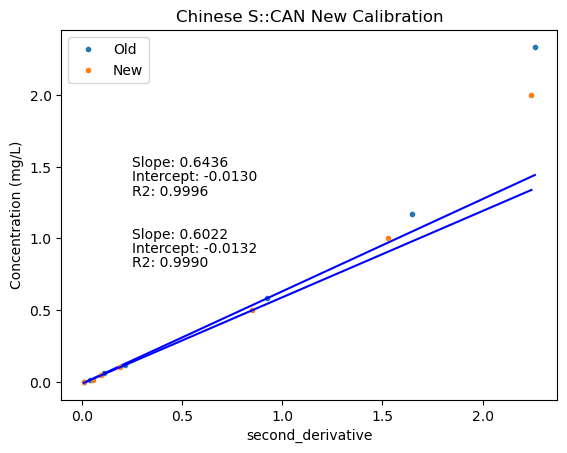

In [6]:
fig, ax = plt.subplots()
chinesecal_21425_old.plot(y='Concentration (mg/L) Correct', x='second_derivative', marker='.', linestyle = 'None', title = 'Chinese S::CAN Old Calibration', ylabel = 'Concentration (mg/L)', label='Old', ax=ax)
plot_linear_fit(chinesecal_21425_old, chinesecal_21425_old[0:5], 'second_derivative', 'Concentration (mg/L) Correct', .25, 1.5, .1, ax=ax)

chinesecal_21425.plot(y='Concentration (mg/L)', x='second_derivative', marker='.', linestyle = 'None', title = 'Chinese S::CAN New Calibration', ylabel = 'Concentration (mg/L)', label='New', ax=ax)
plot_linear_fit(chinesecal_21425, chinesecal_21425[0:5], 'second_derivative', 'Concentration (mg/L)', .25, 1, .1, ax=ax)

- why don't old and new calibration curves match up when corrected? the correction factor for the old standards seems to be 1.1, not 1.168 as the last standard run would indicate... 

# Ocean S::CAN

In [34]:
oceancal_12225 = scan_helpers.import_scan_fp('/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/Boise Project/Data/SCAN Calibration 1-22-25/calibration.fp')
oceancal_12225['Concentration (mg/L)'] = [0, .01, .05, .1, .5, 1, 2]
oceancal_12225['Concentration (mg/L) Correct'] = oceancal_12225['Concentration (mg/L)']*1.168
oceancal_12225['Concentration (uM)'] = oceancal_12225['Concentration (mg/L) Correct']*1000/14
oceancal_12225 = scan_helpers.apply_calibrations(oceancal_12225, [no3_calibrations.one_wavelength, no3_calibrations.two_wavelength, no3_calibrations.second_derivative], {no3_calibrations.second_derivative: {'output_calibrated':False}, no3_calibrations.two_wavelength: {'output_calibrated':False}, no3_calibrations.one_wavelength: {'output_calibrated':False}})

oceancal_12225_corrected = scan_helpers.correct_turbidity(oceancal_12225.drop(['Concentration (mg/L)','Concentration (mg/L) Correct', 'Concentration (uM)', 'one_wavelength', 'two_wavelength', 'second_derivative'], axis=1))
oceancal_12225_corrected['Concentration (mg/L)'] = oceancal_12225['Concentration (mg/L)']
oceancal_12225_corrected['Concentration (mg/L) Correct'] = oceancal_12225['Concentration (mg/L) Correct']
oceancal_12225_corrected['Concentration (uM)'] = oceancal_12225_corrected['Concentration (mg/L) Correct']*1000/14
oceancal_12225_corrected = scan_helpers.apply_calibrations(oceancal_12225_corrected, [no3_calibrations.one_wavelength, no3_calibrations.two_wavelength, no3_calibrations.second_derivative], {no3_calibrations.second_derivative: {'output_calibrated':False}, no3_calibrations.two_wavelength: {'output_calibrated':False}, no3_calibrations.one_wavelength: {'output_calibrated':False}})

oceancal_12225_corrected

,200.0,202.5,205.0,207.5,210.0,212.5,215.0,217.5,220.0,222.5,...,742.5,745.0,747.5,750.0,Concentration (mg/L),Concentration (mg/L) Correct,Concentration (uM),one_wavelength,two_wavelength,second_derivative
Date/Time,,,,,,,,,,,,,,,,,,,,,
2025-01-22 16:40:24,0.144434,0.099059,0.067822,0.032223,0.003062,0.005641,0.010959,0.006716,0.007714,-0.004746,...,NaN,NaN,NaN,NaN,0.00,0.00000,0.000000,0.007714,0.036528,0.003542
2025-01-22 17:41:44,-0.011725,0.093268,0.153607,0.156593,0.146025,0.133203,0.107127,0.079696,0.052510,-0.000031,...,NaN,NaN,NaN,NaN,0.01,0.01168,0.834286,0.052510,0.101714,0.005944
2025-01-22 17:45:36,1.451333,1.564407,1.583436,1.476626,1.249883,0.980013,0.678723,0.357918,0.063805,-0.197410,...,NaN,NaN,NaN,NaN,0.05,0.05840,4.171429,0.063805,0.807466,0.084716
2025-01-22 17:48:07,3.170698,3.326565,3.317431,3.062412,2.569120,1.966270,1.307676,0.658251,0.094609,-0.412135,...,NaN,NaN,NaN,NaN,0.10,0.11680,8.342857,0.094609,1.643768,0.188539
2025-01-22 17:50:39,15.053488,15.628865,15.285137,13.632272,10.940737,8.257499,5.744128,3.173789,0.763151,-1.518018,...,NaN,NaN,NaN,NaN,0.50,0.58400,41.714286,0.763151,7.896417,0.961771
2025-01-22 17:53:06,19.077166,20.197579,20.011626,17.623407,14.233724,11.781076,9.934464,7.664288,4.739848,1.033945,...,NaN,NaN,NaN,NaN,1.00,1.16800,83.428571,4.739848,15.526683,1.713738
2025-01-22 17:55:30,17.446322,18.876396,18.968818,16.762709,13.708089,11.930281,11.550504,12.024979,11.928528,8.910770,...,NaN,NaN,NaN,NaN,2.00,2.33600,166.857143,11.928528,25.501873,2.455757


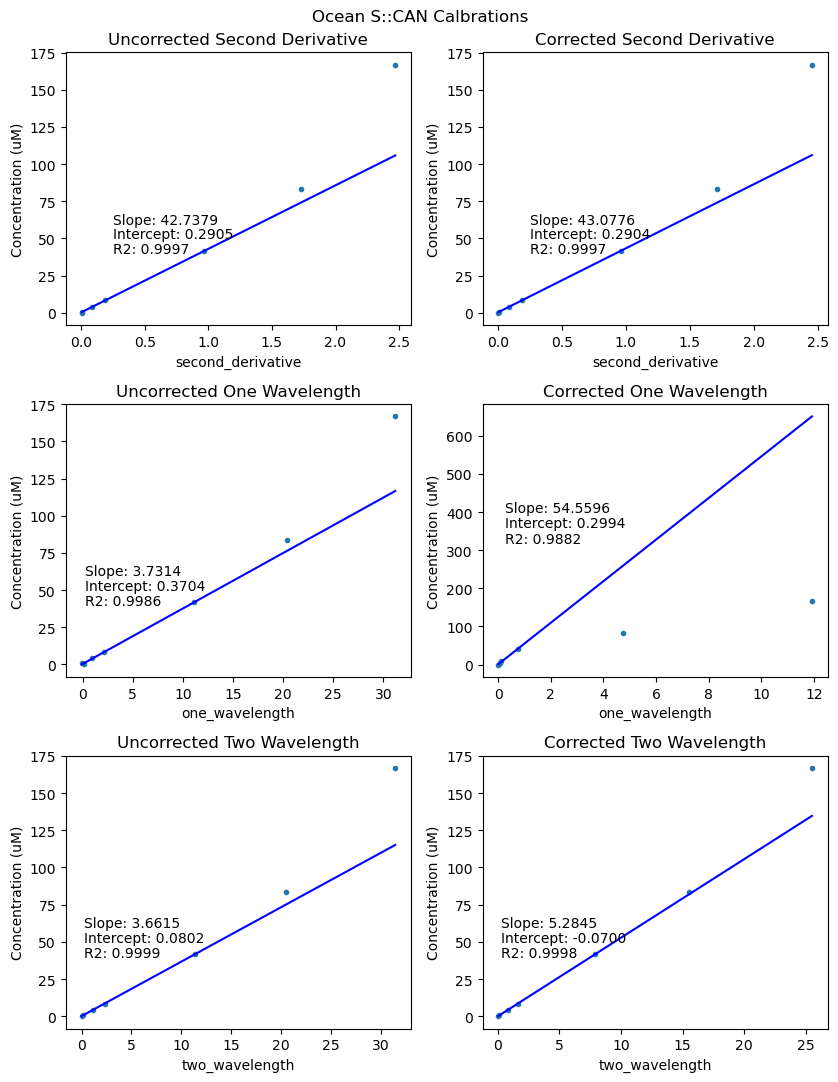

In [38]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(8.5,11))
oceancal_12225.plot(y='Concentration (uM)', x='second_derivative', marker='.', linestyle = 'None', title = 'Uncorrected Second Derivative', ylabel = 'Concentration (uM)', legend=False, ax=ax[0,0])
plot_linear_fit(oceancal_12225, oceancal_12225[0:5], 'second_derivative', 'Concentration (uM)', .25, 60, 10, ax=ax[0,0])

oceancal_12225.plot(y='Concentration (uM)', x='one_wavelength', marker='.', linestyle = 'None', title = 'Uncorrected One Wavelength', ylabel = 'Concentration (uM)', legend=False, ax=ax[1,0])
plot_linear_fit(oceancal_12225, oceancal_12225[0:5], 'one_wavelength', 'Concentration (uM)', .25, 60, 10, ax=ax[1,0])

oceancal_12225.plot(y='Concentration (uM)', x='two_wavelength', marker='.', linestyle = 'None', title = 'Uncorrected Two Wavelength', ylabel = 'Concentration (uM)', legend=False, ax=ax[2,0])
plot_linear_fit(oceancal_12225, oceancal_12225[0:5], 'two_wavelength', 'Concentration (uM)', .25, 60, 10, ax=ax[2,0])

oceancal_12225_corrected.plot(y='Concentration (uM)', x='second_derivative', marker='.', linestyle = 'None', title = 'Corrected Second Derivative', ylabel = 'Concentration (uM)', legend=False, ax=ax[0,1])
plot_linear_fit(oceancal_12225_corrected, oceancal_12225_corrected[0:5], 'second_derivative', 'Concentration (uM)', .25, 60, 10, ax=ax[0,1])

oceancal_12225_corrected.plot(y='Concentration (uM)', x='one_wavelength', marker='.', linestyle = 'None', title = 'Corrected One Wavelength', ylabel = 'Concentration (uM)', legend=False, ax=ax[1,1])
plot_linear_fit(oceancal_12225_corrected, oceancal_12225_corrected[0:5], 'one_wavelength', 'Concentration (uM)', .25, 400, 40, ax=ax[1,1])

oceancal_12225_corrected.plot(y='Concentration (uM)', x='two_wavelength', marker='.', linestyle = 'None', title = 'Corrected Two Wavelength', ylabel = 'Concentration (uM)', legend=False, ax=ax[2,1])
plot_linear_fit(oceancal_12225_corrected, oceancal_12225_corrected[0:5], 'two_wavelength', 'Concentration (uM)', .25, 60, 10, ax=ax[2,1])


fig.suptitle('Ocean S::CAN Calbrations')
fig.tight_layout()

Uncorrected
- calibration for the ocean s::Can (current at RME) also looks good - linear to .5 mg/L, LOD somewhere betweenm .01 and .05 mg/L (expected is .14)
- pretty similar slopes to chinese s::can
- 
Corrected
- similarly small effect for second derivative
- one wavelength corrected is quite bad, 2nd derivative works well